In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import cftime
import sys
import os
import pandas as pd

calc_annual = False
read_last_n = False
read_first_n = False
nfiles = 170

#Additional plots
plot_total = True

# Conversion factors
km2_to_m2 = 1e6
kg_to_Gt = 1e-12
CO2_to_C = 12.011 / 44.01  # Conversion factor from CO2 to C
seconds_per_year = 365 * 24 * 60 * 60
days_per_year = 365
days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
sec_per_month = [days * 24 * 60 * 60 for days in days_per_month]




In [2]:
# open the results from the feb and may run
df_feb = pd.read_csv('nbp_timeseries_februn.csv')
df_may = pd.read_csv('nbp_timeseries_mayrun.csv')

In [3]:
# read in GCP data - note units are GtC yr-1 
GCP = pd.read_csv('/datalake/NS9188K/share/jessien/S3_nbp_transposed.csv')

GCP.head(3)

# get just years 1900-2020
GCP = GCP[(GCP['Year'] >= 1851) & (GCP['Year'] <= 2020)]
print(GCP.head(3))

years = GCP['Year'].values

# make a column with the multi model mean 
GCP['MMM'] = GCP.iloc[:, 1:].mean(axis=1)


     Year  CABLE-POP  CARDAMOM   CLASSIC  CLM-FATES    CLM6.0      DLEM  \
151  1851  -1.357065       NaN -1.653368   0.672055 -0.809547 -0.691224   
152  1852   1.568562       NaN -0.540416  -0.032936 -0.559854 -0.761941   
153  1853  -0.661550       NaN -0.879205  -0.222830 -0.802037 -0.662190   

         E3SM      EDv3  ELM-FATES  ...      IBIS      ISAM    JSBACH  \
151 -0.201757 -0.214878  -0.506455  ... -0.167928 -0.888839 -1.367418   
152 -0.335420  0.677266   0.322207  ... -0.405382 -0.404104  0.298546   
153  0.055167 -0.577592  -0.031307  ...  0.296156 -0.380472 -0.313253   

        JULES  LPJ-EOSIM  LPJ-GUESS     LPJmL  LPX-Bern  ORCHIDEE  VISIT-UT  
151 -0.656205   0.104561  -1.104672 -1.221612 -1.328976 -0.668774 -0.381190  
152 -0.452577  -0.716608  -1.471057 -0.704279 -0.895584 -0.404447 -0.992913  
153 -0.289864   0.432230  -0.731686  1.141919 -0.583003 -0.099610  0.284739  

[3 rows x 21 columns]


In [4]:
time = np.linspace(1851, 2020, len(df_feb["FCO2"]))

In [5]:
tmp = df_feb.to_xarray()
tmp = tmp['FCO2'].values

tmp_may = df_may.to_xarray()
tmp_may = tmp_may['FCO2'].values

In [6]:
yearly_avgs_feb = np.sum(tmp.reshape((len(tmp)//12, 12)), axis=1)
time_yrs = np.linspace(1851, 2020, len(yearly_avgs_feb))

yearly_avgs_may = np.sum(tmp_may.reshape((len(tmp_may)//12, 12)), axis=1)
time_yrs_may = np.linspace(1851, 2000, len(yearly_avgs_may))


Number of years in FCO2: 170.0


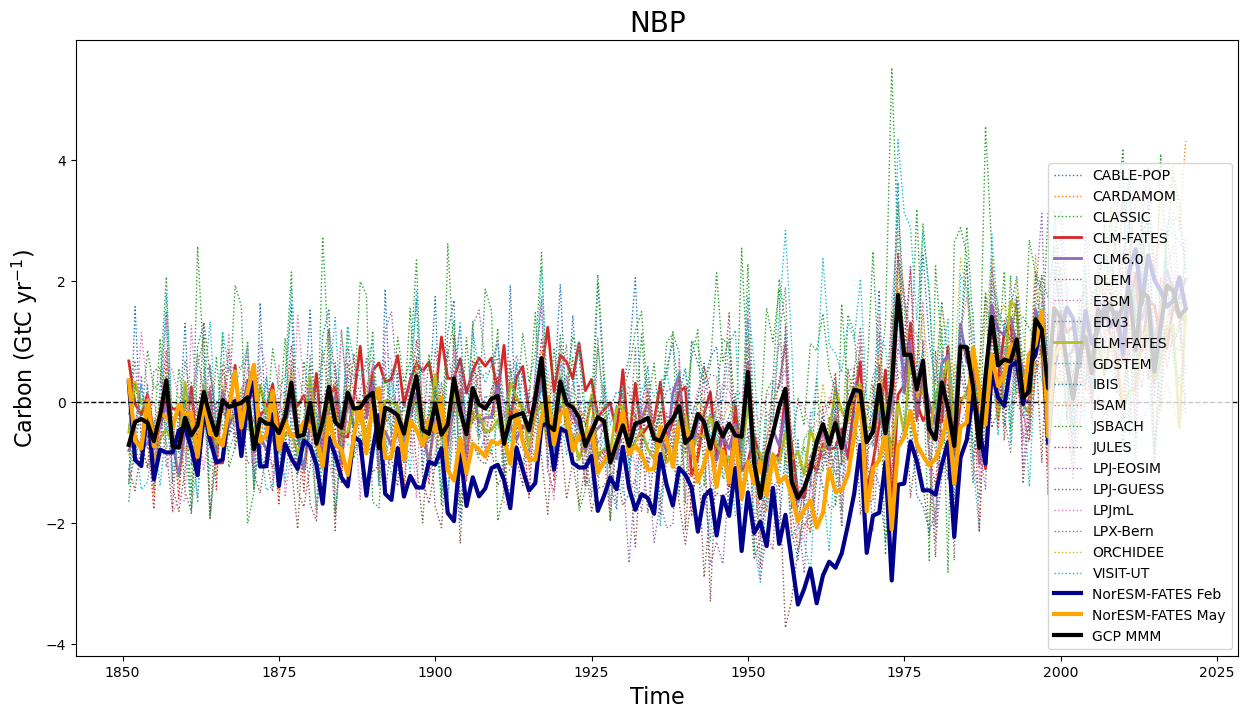

In [7]:

nyears = tmp.shape[0] / 12
print(f'Number of years in FCO2: {nyears}')

# Plotting
figTot, axes = plt.subplots(1, 1, figsize=(15, 8))


#axes.fill_between(years, lower_uncert, upper_uncert, alpha=0.2, label='GCP uncertainty')

for i in range(1, (GCP.shape[1] -1)):
    model_name = GCP.columns[i]
    model_data = GCP[model_name].values
    if model_name in ['CLM-FATES', 'ELM-FATES', 'CLM6.0']:
        axes.plot(years, model_data, label=model_name, linewidth=2)
    else:    
        axes.plot(years, model_data, label=model_name, linestyle=':', linewidth=1)

axes.plot(time_yrs, -yearly_avgs_feb, label="NorESM-FATES Feb", linestyle='-', linewidth=3, color='darkblue')
axes.plot(time_yrs_may, -yearly_avgs_may, label="NorESM-FATES May", linestyle='-', linewidth=3, color='orange')
axes.plot(years, GCP['MMM'], label='GCP MMM', linewidth=3, color='black')    

   
axes.set_title('NBP', fontsize=20)
axes.set_ylabel(r'Carbon (GtC yr$^{-1}$)', fontsize=16)
axes.set_xlabel('Time', fontsize=16)
#axes.grid(True)
# add a horizontal line at y=0
axes.axhline(0, color='black', linestyle='--', linewidth=1)
axes.legend()